# CNN 모델 비교 학습 템플릿

`dataset/train`, `dataset/val`, `dataset/test` 폴더를 사용해서 모델만 바꿔가며 비교하는 노트북입니다.

모델을 바꿀 때는 **3. 모델 만들기** 셀의 주석 표시된 부분만 수정하면 됩니다.

In [1]:
from pathlib import Path
import copy
import random
import time

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

c:\Projects\focus_on_class\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 고정 설정

비교 실험에서는 아래 값들을 모델이 바뀌어도 그대로 두는 것을 권장합니다.

In [2]:
data_path = Path("dataset")
save_path = Path("models")
save_path.mkdir(exist_ok=True)

# 저장될 파일 이름에 들어갈 모델명입니다.
# 사용할 모델에 맞게 아래 이름 중 하나로 바꾸세요.
# ResNet18          -> "resnet18"
# ResNet34          -> "resnet34"
# ResNet50          -> "resnet50"
# MobileNetV3-Large -> "mobilenet_v3_large"
# EfficientNet-B0   -> "efficientnet_b0"
# EfficientNet-B2   -> "efficientnet_b2"
# EfficientNet-B3   -> "efficientnet_b3"
# EfficientNetV2-S  -> "efficientnet_v2_s"
model_name = "efficientnet_b0"
image_size = 224
batch_size = 16
epochs = 20
learning_rate = 1e-4
weight_decay = 0.5
seed = 42

# Keep this False while comparing candidate models.
# After choosing the final model by validation F1, set this True and run test once.
run_final_test = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. 데이터 불러오기

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [5]:
train_data = datasets.ImageFolder(data_path / "train", transform=train_transform)
val_data = datasets.ImageFolder(data_path / "val", transform=test_transform)
test_data = datasets.ImageFolder(data_path / "test", transform=test_transform)

class_names = train_data.classes
class_count = len(class_names)

print(class_names)
print("train:", len(train_data), "val:", len(val_data), "test:", len(test_data))

['Attentive', 'Drowsy', 'LookingAway']
train: 1345 val: 171 test: 167


In [6]:
shuffle_seed = torch.Generator().manual_seed(seed)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, generator=shuffle_seed)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## 3. 모델 만들기

위 `model_name`에 적은 이름에 맞춰 pretrained 모델을 불러옵니다.

모델을 바꿀 때는 **1. 고정 설정** 셀의 `model_name`만 바꾸면 됩니다.

In [ ]:
def change_fc(model, class_count):
    model.fc = nn.Linear(model.fc.in_features, class_count)
    return model


def change_classifier(model, class_count):
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, class_count)
    return model

# 모델 이름: [모델 함수, pretrained weights, 마지막 층 바꾸는 함수]
model_list = {
    "resnet18": [models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1, change_fc],
    "resnet34": [models.resnet34, models.ResNet34_Weights.IMAGENET1K_V1, change_fc],
    "resnet50": [models.resnet50, models.ResNet50_Weights.IMAGENET1K_V1, change_fc],
    "mobilenet_v3_large": [models.mobilenet_v3_large, models.MobileNet_V3_Large_Weights.IMAGENET1K_V2, change_classifier],
    "efficientnet_b0": [models.efficientnet_b0, models.EfficientNet_B0_Weights.IMAGENET1K_V1, change_classifier],
    "efficientnet_b2": [models.efficientnet_b2, models.EfficientNet_B2_Weights.IMAGENET1K_V1, change_classifier],
    "efficientnet_b3": [models.efficientnet_b3, models.EfficientNet_B3_Weights.IMAGENET1K_V1, change_classifier],
    "efficientnet_v2_s": [models.efficientnet_v2_s, models.EfficientNet_V2_S_Weights.IMAGENET1K_V1, change_classifier],
}


model_func, weights, change_last_layer = model_list[model_name]
model = model_func(weights=weights)
model = change_last_layer(model, class_count).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## 4. 학습 함수

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [9]:
def train_one_epoch():
    model.train()
    total_loss = 0
    y_true = []
    y_pred = []

    for x, y in tqdm(train_loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        y_true += y.cpu().tolist()
        y_pred += pred.argmax(1).cpu().tolist()

    return total_loss / len(train_data), accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro")


def evaluate(loader, data):
    model.eval()
    total_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in tqdm(loader, leave=False):
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            y_true += y.cpu().tolist()
            y_pred += pred.argmax(1).cpu().tolist()

    return total_loss / len(data), accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro"), y_true, y_pred

## 5. 학습하기

In [10]:
history = []
best_score = 0
best_model = copy.deepcopy(model.state_dict())

for epoch in range(1, epochs + 1):
    train_loss, train_acc, train_f1 = train_one_epoch()
    val_loss, val_acc, val_f1, _, _ = evaluate(val_loader, val_data)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    })

    print(f"{epoch:02d}/{epochs} | train acc {train_acc:.4f} f1 {train_f1:.4f} | val acc {val_acc:.4f} f1 {val_f1:.4f}")

    if val_f1 > best_score:
        best_score = val_f1
        best_model = copy.deepcopy(model.state_dict())

history_df = pd.DataFrame(history)
history_df

01/20 | train acc 0.7584 f1 0.7578 | val acc 0.9298 f1 0.9310


02/20 | train acc 0.9190 f1 0.9184 | val acc 0.9591 f1 0.9584


03/20 | train acc 0.9420 f1 0.9418 | val acc 0.9708 f1 0.9710


04/20 | train acc 0.9524 f1 0.9521 | val acc 0.9766 f1 0.9772


05/20 | train acc 0.9606 f1 0.9604 | val acc 0.9825 f1 0.9829


...

17/20 | train acc 0.9851 f1 0.9850 | val acc 0.9766 f1 0.9765


18/20 | train acc 0.9911 f1 0.9911 | val acc 0.9883 f1 0.9886


19/20 | train acc 0.9911 f1 0.9911 | val acc 0.9766 f1 0.9769


20/20 | train acc 0.9926 f1 0.9925 | val acc 0.9883 f1 0.9886


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.659436,0.758364,0.757819,0.246884,0.929825,0.931018
1,2,0.263320,0.918959,0.918413,0.127743,0.959064,0.958424
2,3,0.182152,0.942007,0.941838,0.106798,0.970760,0.971020
3,4,0.141556,0.952416,0.952111,0.109495,0.976608,0.977166
4,5,0.117412,0.960595,0.960406,0.093312,0.982456,0.982886
5,6,0.112972,0.961338,0.961206,0.086482,0.982456,0.982634
6,7,0.068344,0.982156,0.982251,0.087229,0.970760,0.971502
7,8,0.064644,0.979926,0.979934,0.102871,0.970760,0.970953
8,9,0.081874,0.969517,0.969345,0.076594,0.970760,0.971207
9,10,0.064847,0.979182,0.979318,0.074069,0.976608,0.976773


In [11]:
model.load_state_dict(best_model)
best_row = history_df.loc[history_df["val_f1"].idxmax()].to_dict()
checkpoint_path = save_path / f"{model_name}_best.pt"

torch.save({
    "model_state": model.state_dict(),
    "class_names": class_names,
    "image_size": image_size,
    "model_name": model_name,
    "best_val": best_row,
}, checkpoint_path)

print(f"saved: {checkpoint_path}")
print(f"best validation f1: {best_row['val_f1']:.4f} at epoch {int(best_row['epoch'])}")
checkpoint_path

saved: models\efficientnet_b0_best.pt
best validation f1: 0.9886 at epoch 18


WindowsPath('models/efficientnet_b0_best.pt')

## 6. 최종 test 평가

모델 비교 중에는 이 셀을 실행하지 않습니다. 후보 모델은 `val_f1`로 비교하고, 최종 선택한 모델에서만 `run_final_test = True`로 바꾼 뒤 test를 1회 실행합니다.

In [12]:
if not run_final_test:
    print("모델 비교 중이므로 test 평가는 건너뜁니다.")
    print("최종 모델을 고른 뒤 run_final_test = True로 바꾸고 이 셀을 1회만 실행하세요.")
else:
    start_time = time.perf_counter()
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(test_loader, test_data)
    test_time = time.perf_counter() - start_time

    print(f"test loss: {test_loss:.4f}")
    print(f"test acc : {test_acc:.4f}")
    print(f"test f1  : {test_f1:.4f}")
    print(f"time     : {test_time:.4f} sec / {test_time / len(test_data) * 1000:.3f} ms per image")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


test loss: 0.0582
test acc : 0.9940
test f1  : 0.9941
time     : 0.3314 sec / 1.985 ms per image

              precision    recall  f1-score   support

   Attentive     1.0000    1.0000    1.0000        53
      Drowsy     0.9831    1.0000    0.9915        58
 LookingAway     1.0000    0.9821    0.9910        56

    accuracy                         0.9940       167
   macro avg     0.9944    0.9940    0.9941       167
weighted avg     0.9941    0.9940    0.9940       167



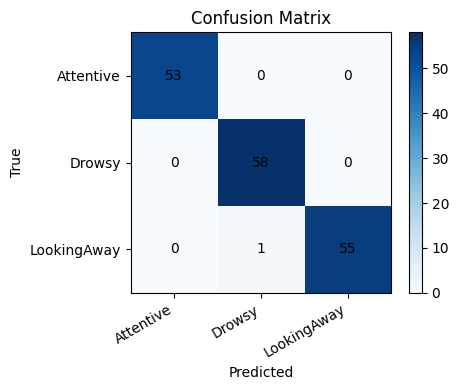

In [13]:
if not run_final_test:
    print("test 평가를 건너뛰었으므로 confusion matrix도 생성하지 않습니다.")
else:
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(class_count), class_names, rotation=30, ha="right")
    plt.yticks(range(class_count), class_names)

    for i in range(class_count):
        for j in range(class_count):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

## 비교를 위해 고정하면 좋은 것

- 데이터셋 폴더와 train/val/test 분할
- 클래스 이름과 클래스 순서
- 이미지 크기와 Normalize 값
- train 증강 방식
- batch size, epoch, optimizer, learning rate, weight decay
- random seed
- pretrained 사용 여부
- backbone freeze 여부
- best model 선택 기준: 현재는 `val_f1`
- 평가 지표: Accuracy, Macro F1, 추론 시간